<table>
<tr>
<td><table><tr><td><h1>Clasificación de Ruido Mixto y Denoising -- Rama híbrida cuántico-clásica: HQNN + ConvHQVAE</h1></td></tr>
<tr><td><h3>Comparación clásica vs. híbrida cuántico-clásica con análisis de explicabilidad (XAI)</h3></td></tr></table></td>
</tr>
</table>


**Objetivo de este notebook**:

Este notebook ejecuta la **rama híbrida cuántico-clásica** del estudio comparativo: una HQNN (CNN + QNN variacional vía `EstimatorQNN`/`TorchConnector`) para clasificación de ruido mixto, y un ConvHQVAE (ConvVAE + QNN en el espacio latente) para denoising. Ambas arquitecturas reproducen exactamente la configuración ya entrenada en `HCQNN4_ZZFM_full__r1_RA_rlinear_r1_adamw_fc_final_Identity_42` y `HQVAE6_ZZFM_full_RA_linear_r1_adamw_12_42`. Se incorpora además una batería de técnicas de *Explainable AI (XAI)* -- las mismas aplicadas en `Classical_CNN_VAE.ipynb` y en el notebook gemelo `Classical_CNN_CVAE.ipynb` -- adaptadas a un contexto NISQ, para permitir una comparación directa de interpretabilidad clásica vs. híbrida.

**Notebook gemelo**: para la comparación completa, ejecutar también `Classical_CNN_CVAE.ipynb` (rama clásica).

**Índice**:

1. Preprocesamiento de datos y modelización del ruido mixto

2. Clasificación de ruido con HQNN híbrida (CNN + QNN)

3. Denoising con ConvHQVAE híbrido (ConvVAE + QNN)

4. Explicabilidad (XAI) del clasificador

5. Explicabilidad (XAI) del modelo de denoising

6. Conclusiones y guía de comparación con el notebook gemelo

## 1. Preprocesamiento de datos y modelización del ruido mixto

### 1.1. Imports

Se reutiliza exactamente el mismo pipeline de datos y de generación de ruido mixto empleado en las ejecuciones de referencia (HCQNN4), de forma que ambos notebooks (clásico e híbrido) sean comparables celda a celda.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from common_utils import (
    plot_training_curves,
    plot_confusion_matrix,
    evaluate_model,
    mostrar_reconstrucciones,
)
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector


### 1.2. Reproducibilidad (semilla)

In [2]:
import random
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed fijada: {SEED}")

Seed fijada: 42


### 1.3. Carga de MNIST y submuestreo

Se utilizan, deliberadamente, muestras reducidas de entrenamiento, validación y test: el objetivo del estudio es comparar la versión clásica frente a la híbrida cuántico-clásica, y esta última exige un número reducido de muestras por el coste computacional de simular circuitos cuánticos en local.

- training dataset: 400 muestras (300 entrenamiento + 100 validación)
- test dataset: 100 muestras

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

X_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [4]:
n_samples_train = 400
n_samples_test = 100

X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]

X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

In [5]:
train_size = 300
val_size = 100

split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_subset, val_subset = random_split(
    X_train,
    [train_size, val_size],
    generator=split_generator
)

### 1.4. Modelización del ruido mixto

Se definen tres degradaciones estocásticas sobre la imagen original $x$:

**Ruido Gaussiano** ($\sigma = 0.25$):
$$x_{\text{gaussian}} = \text{clip}\left(x + \mathcal{N}(0, \sigma^2),\ 0,\ 1\right)$$

**Ruido de Sal y Pimienta** (prob $= 0.15$): sustituye una fracción de píxeles por $0$ o $1$ de forma equiprobable.

**Ruido Speckle** (multiplicativo, $\sigma = 0.35$):
$$x_{\text{speckle}} = \text{clip}\left(x + x \cdot \mathcal{N}(0, \sigma^2),\ 0,\ 1\right)$$

Cada imagen recibe una combinación aleatoria de dos de estos tres ruidos, lo que define las tres clases objetivo de la tarea de clasificación:

| Clase | Combinación de ruido |
|---|---|
| 0 | Gaussiano + Speckle |
| 1 | Gaussiano + Sal y Pimienta |
| 2 | Sal y Pimienta + Speckle |

A diferencia de `Classical_CNN_VAE.ipynb`, aquí el ruido se genera con un `torch.Generator` explícito por partición (train/val/test), replicando la versión reproducible usada en las ejecuciones de referencia HCQNN4/HQVAE6.

In [6]:
def gaussian_noise(img, sigma=0.25, generator=None):
    noise = torch.randn(img.shape, generator=generator, dtype=img.dtype) * sigma
    return torch.clamp(img + noise, 0, 1)


def salt_pepper(img, prob=0.15, generator=None):
    noisy = img.clone()
    mask = torch.rand(img.shape, generator=generator, dtype=img.dtype)
    noisy[mask < prob / 2] = 0
    noisy[mask > 1 - prob / 2] = 1
    return noisy


def speckle(img, sigma=0.35, generator=None):
    noise = torch.randn(img.shape, generator=generator, dtype=img.dtype) * sigma
    return torch.clamp(img + img * noise, 0, 1)


def apply_mixed_noise(img, generator):
    r = torch.randint(low=0, high=3, size=(1,), generator=generator).item()

    if r == 0:
        img = gaussian_noise(img, generator=generator)
        img = speckle(img, generator=generator)
        label = 0
    elif r == 1:
        img = gaussian_noise(img, generator=generator)
        img = salt_pepper(img, generator=generator)
        label = 1
    else:
        img = salt_pepper(img, generator=generator)
        img = speckle(img, generator=generator)
        label = 2

    return img, label

### 1.5. Datasets y DataLoaders para clasificación

In [7]:
class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, seed):
        self.mnist = mnist_dataset
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.labels = []

        for img, _ in self.mnist:
            noisy_img, label = apply_mixed_noise(img, generator=self.generator)
            self.noisy_images.append(noisy_img)
            self.labels.append(label)

        if len(self.noisy_images) != len(self.labels):
            raise Exception("Incompatible arrays")

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]


train_dataset = NoisyMNISTDataset(train_subset, seed=SEED)
val_dataset   = NoisyMNISTDataset(val_subset, seed=SEED + 1)
test_dataset  = NoisyMNISTDataset(X_test, seed=SEED + 2)

In [8]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=train_generator)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)  # [32, 1, 28, 28]
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


## 2. Clasificación de ruido con HQNN híbrida (CNN + QNN)

### 2.1. Bloque cuántico: `EstimatorQNN`

El circuito variacional opera sobre 4 qubits y combina:

- **Feature map**: `zz_feature_map(4, entanglement="full", reps=1)` -- codifica el vector clásico de 4 ángulos (salida de `fc2`, acotada a $[-\pi,\pi]$) mediante rotaciones $R_z$ y entrelazamiento $ZZ$ completo entre todos los pares de qubits.
- **Ansatz**: `real_amplitudes(4, entanglement="reverse_linear", reps=1)` -- circuito variacional parametrizado (los pesos entrenables de la QNN).
- **Observables**: 3 operadores de Pauli (combinaciones $Z$ y $ZZ$) cuyo valor esperado produce directamente los 3 logits de clase -- no se añade ninguna capa lineal adicional (`fc_final = nn.Identity()`).

El `Estimator` utilizado es `StatevectorEstimator`: realiza una simulación exacta (sin ruido de shots), coherente con un régimen de estudio NISQ idealizado en el que el interés se centra en la expresividad del circuito variacional más que en el ruido hardware. `input_gradients=True` habilita la propagación de gradientes a través de la QNN, imprescindible para el entrenamiento híbrido end-to-end vía `TorchConnector`.

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


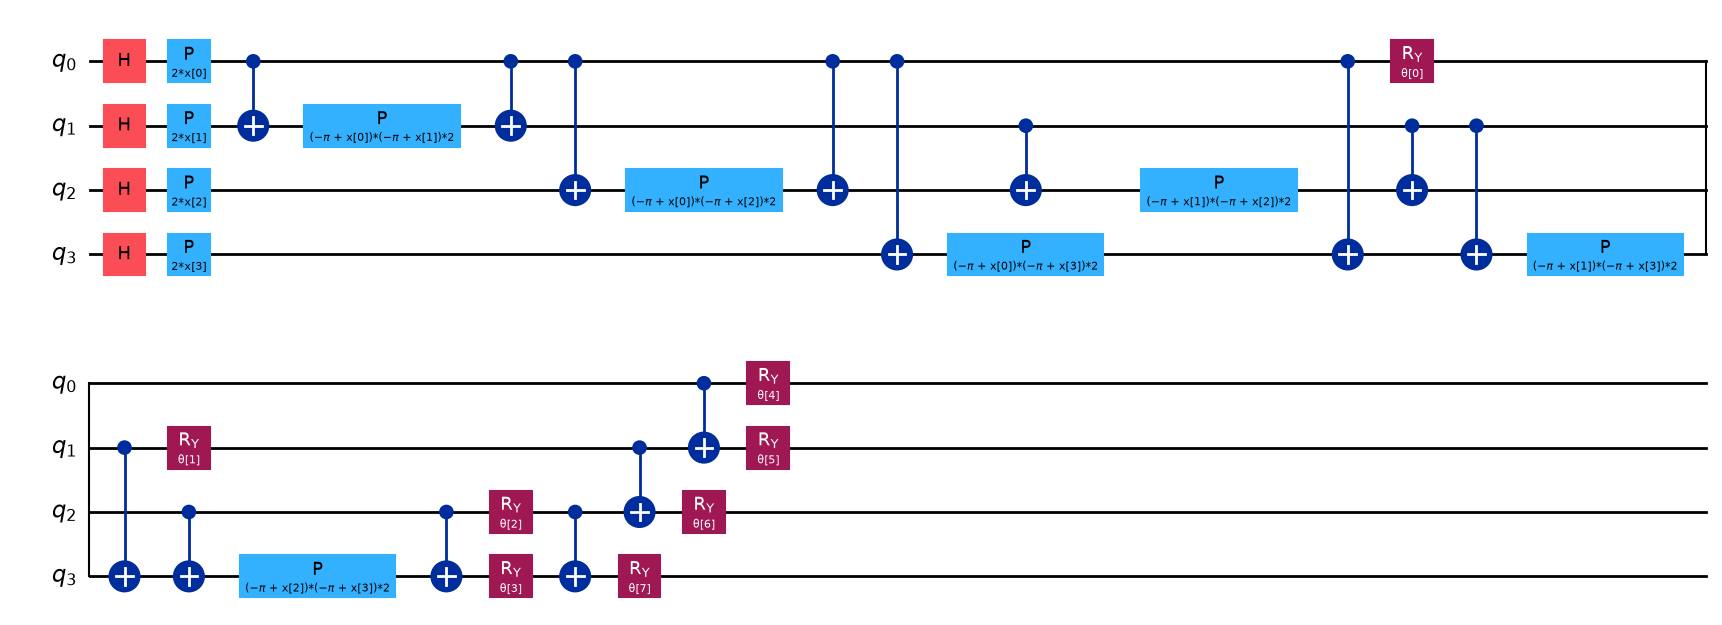

In [9]:
from qiskit.circuit.library import zz_feature_map, real_amplitudes

estimator = Estimator()

observables = [
    SparsePauliOp.from_list([("ZIII", 1.0), ("IZII", 1.0)]),
    SparsePauliOp.from_list([("ZZII", 1.0)]),
    SparsePauliOp.from_list([("IIZZ", 1.0)]),
]


def create_qnn():
    feature_map = zz_feature_map(4, entanglement="full", reps=1)
    ansatz = real_amplitudes(4, entanglement="reverse_linear", reps=1)

    qc = QuantumCircuit(4)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=estimator,
        observables=observables,
    )
    return qnn


qnn_clf = create_qnn()
qnn_clf.circuit.draw("mpl")

### 2.2. Arquitectura híbrida completa

El extractor convolucional es **idéntico** al de la rama clásica (`conv1`, `conv2`, `fc1`, `fc2`): la única diferencia arquitectónica es que, tras el `tanh(·)·π`, el vector 4D se envía a la QNN (vía `TorchConnector`, que expone el circuito variacional como una capa diferenciable de PyTorch) en lugar de a un `feature_mixer` clásico. La salida de la QNN son directamente los 3 logits de clase.

In [10]:
class Net(nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 4)

        self.qnn = TorchConnector(qnn)
        self.fc_final = nn.Identity()

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x)) * np.pi

        x = self.qnn(x)
        x = self.fc_final(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_clf = Net(qnn_clf).to(device)
model_clf

Net(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (qnn): TorchConnector()
  (fc_final): Identity()
)

### 2.3. Entrenamiento

Se reproduce el protocolo de entrenamiento exacto de la ejecución de referencia HCQNN4: `AdamW` (lr=1e-3), 10 épocas máximas y *early stopping* con paciencia 3 sobre la pérdida de validación. Cada paso de `loss.backward()` retropropaga a través de la QNN mediante el gradiente analítico expuesto por `EstimatorQNN`.

In [11]:
optimizer_clf = optim.AdamW(model_clf.parameters(), lr=1e-3)
criterion_clf = nn.CrossEntropyLoss()

epochs = 10
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

start_time = time.time()
patience = 3
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):

    model_clf.train()
    total_loss, correct, total = 0, 0, 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer_clf.zero_grad()
        output = model_clf(data)
        loss = criterion_clf(output, target)
        loss.backward()
        optimizer_clf.step()

        total_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    avg_train_loss = total_loss / total
    train_acc = correct / total
    train_loss_list.append(avg_train_loss)
    train_acc_list.append(train_acc)

    model_clf.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model_clf(data)
            loss = criterion_clf(output, target)
            val_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output, 1)
            correct += (predicted == target).sum().item()
            total += target.size(0)

    avg_val_loss = val_loss / total
    val_acc = correct / total
    val_loss_list.append(avg_val_loss)
    val_acc_list.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model_clf.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

end_time = time.time()
training_time = end_time - start_time
model_clf.load_state_dict(best_model_state)

print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")

Epoch 1/10 | Train Loss: 1.1026 | Train Acc: 0.3267 | Val Loss: 1.0836 | Val Acc: 0.6100
Epoch 2/10 | Train Loss: 1.0716 | Train Acc: 0.5000 | Val Loss: 0.9929 | Val Acc: 0.6700
Epoch 3/10 | Train Loss: 0.9198 | Train Acc: 0.6600 | Val Loss: 0.8616 | Val Acc: 0.7300
Epoch 4/10 | Train Loss: 0.8548 | Train Acc: 0.6600 | Val Loss: 0.8079 | Val Acc: 0.7100
Epoch 5/10 | Train Loss: 0.8088 | Train Acc: 0.7933 | Val Loss: 0.7664 | Val Acc: 0.9700
Epoch 6/10 | Train Loss: 0.7447 | Train Acc: 0.9900 | Val Loss: 0.7361 | Val Acc: 1.0000
Epoch 7/10 | Train Loss: 0.7141 | Train Acc: 0.9967 | Val Loss: 0.7110 | Val Acc: 1.0000
Epoch 8/10 | Train Loss: 0.6927 | Train Acc: 1.0000 | Val Loss: 0.6913 | Val Acc: 0.9900
Epoch 9/10 | Train Loss: 0.6793 | Train Acc: 1.0000 | Val Loss: 0.6883 | Val Acc: 1.0000
Epoch 10/10 | Train Loss: 0.6684 | Train Acc: 1.0000 | Val Loss: 0.6781 | Val Acc: 1.0000
Tiempo de entrenamiento: 529.85 segundos
Tiempo en minutos y segundos: 8 minutos y 49 segundos


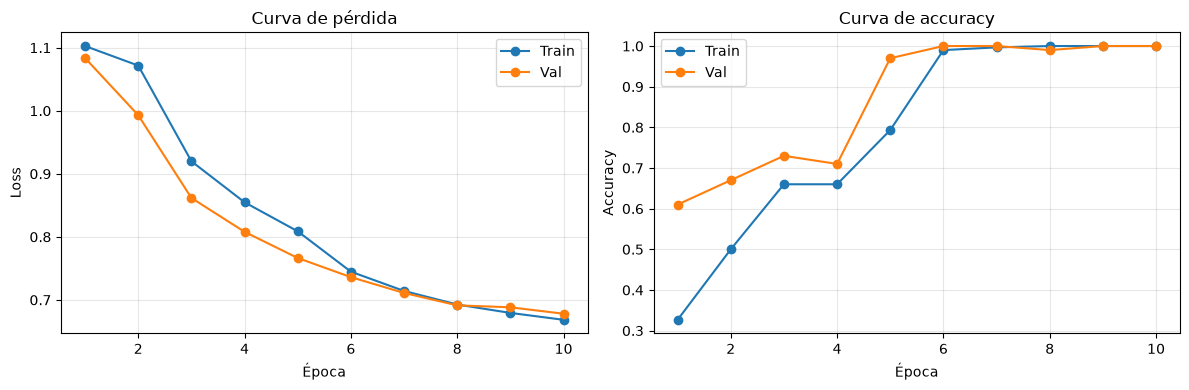

In [12]:
plot_training_curves(train_loss_list, val_loss_list, train_acc_list, val_acc_list)

### 2.4. Evaluación en test y matriz de confusión

Accuracy: 1.0
                     precision    recall  f1-score   support

   gaussian+speckle       1.00      1.00      1.00        31
gaussian+saltpepper       1.00      1.00      1.00        31
 saltpepper+speckle       1.00      1.00      1.00        38

           accuracy                           1.00       100
          macro avg       1.00      1.00      1.00       100
       weighted avg       1.00      1.00      1.00       100



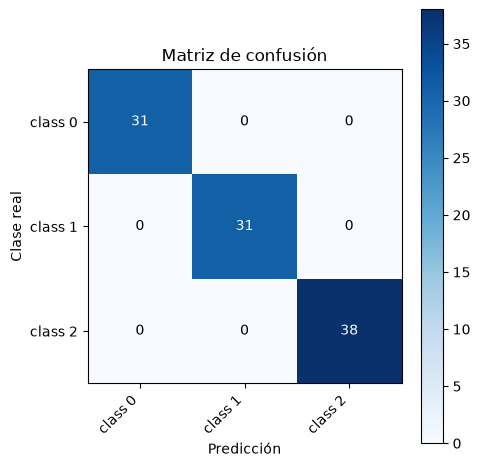

In [13]:
results_clf = evaluate_model(model_clf, test_loader, device)

print("Accuracy:", results_clf["accuracy"])
print(results_clf["report"])

plot_confusion_matrix(
    results_clf["confusion_matrix"],
    ["class 0", "class 1", "class 2"]
)

En la ejecución de referencia (semilla 42, `HCQNN4_..._Identity_42`), este modelo híbrido alcanzó accuracy perfecta (1.0000) en test tras converger en torno a la época 7-8, con matriz de confusión completamente diagonal sobre las 100 muestras de test. La ejecución de este notebook debería reproducir un resultado equivalente al compartir semilla, arquitectura e hiperparámetros; pequeñas variaciones son posibles según la versión de Qiskit/PyTorch instalada.

## 3. Denoising de imágenes

### 3.1. Dataset de denoising

A diferencia de la tarea de clasificación, aquí el objetivo no es predecir una etiqueta sino reconstruir la imagen limpia $x$ a partir de su versión degradada $\tilde{x}$. Se reutilizan las mismas funciones de ruido mixto de la Sección 1, pero ahora cada muestra del dataset es un par (imagen ruidosa, imagen limpia).

In [14]:
class DenoisingMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, seed):
        self.mnist = mnist_dataset
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.clean_images = []

        for img, _ in self.mnist:
            clean_img = img
            noisy_img, _ = apply_mixed_noise(img, generator=self.generator)
            self.clean_images.append(clean_img)
            self.noisy_images.append(noisy_img)

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.clean_images[idx]


train_dataset_dn = DenoisingMNISTDataset(train_subset, seed=SEED)
val_dataset_dn   = DenoisingMNISTDataset(val_subset, seed=SEED + 1)
test_dataset_dn  = DenoisingMNISTDataset(X_test, seed=SEED + 2)

train_generator_dn = torch.Generator()
train_generator_dn.manual_seed(SEED)

train_loader_dn = DataLoader(train_dataset_dn, batch_size=16, shuffle=True, generator=train_generator_dn)
val_loader_dn   = DataLoader(val_dataset_dn, batch_size=16, shuffle=False)
test_loader_dn  = DataLoader(test_dataset_dn, batch_size=16, shuffle=False)

### 3.2. Función de pérdida ($\beta$-VAE)

$$\mathcal{L}_{\text{total}} = \text{BCE}(x,\hat{x}) + \beta \cdot \mathcal{D}_{\text{KL}}\left(\mathcal{N}(\mu,\sigma^2)\,\|\,\mathcal{N}(0,I)\right)$$

con $\beta = 0.5$: se relaja la presión sobre la divergencia KL para priorizar la fidelidad de la reconstrucción (BCE) frente a la regularidad gaussiana del espacio latente, en línea con la justificación dada en `Classical_CNN_VAE.ipynb`.

In [15]:
def vae_loss(recon_x, x, mu, logvar, beta=0.5):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = bce + beta * kl
    return total, bce, kl

### 3.3. Bloque cuántico del espacio latente: `EstimatorQNN` (6 qubits)

El circuito variacional del `ConvHQVAE` opera sobre 6 qubits:

- **Feature map**: `zz_feature_map(6, entanglement="full", reps=1)`
- **Ansatz**: `real_amplitudes(6, entanglement="linear", reps=1)`
- **Observables**: 6 correladores $ZZ$ dispuestos en anillo ($q_0q_1,\,q_1q_2,\,\dots,\,q_5q_0$), capturando correlaciones locales entre qubits vecinos de forma cíclica.

In [16]:
estimator = Estimator()

observables = [  # correlación en anillo
    SparsePauliOp.from_list([("ZZIIII", 1.0)]),  # q0-q1
    SparsePauliOp.from_list([("IZZIII", 1.0)]),  # q1-q2
    SparsePauliOp.from_list([("IIZZII", 1.0)]),  # q2-q3
    SparsePauliOp.from_list([("IIIZZI", 1.0)]),  # q3-q4
    SparsePauliOp.from_list([("IIIIZZ", 1.0)]),  # q4-q5
    SparsePauliOp.from_list([("ZIIIIZ", 1.0)]),  # q5-q0
]


def create_qnn_vae():
    n_qubits = 6
    feature_map = zz_feature_map(n_qubits, reps=1, entanglement="full")
    ansatz = real_amplitudes(n_qubits, entanglement="linear", reps=1)

    qc = QuantumCircuit(n_qubits)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=estimator,
        observables=observables,
    )
    return qnn


qnn_vae = create_qnn_vae()

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


### 3.4. Arquitectura del ConvHQVAE

El encoder, `fc_mu`/`fc_logvar` y el decoder son **idénticos** a los de la rama clásica. La diferencia está en el paso intermedio de `decode()`: el vector latente $z$ (dimensión 12) se proyecta primero a la dimensión de entrada de la QNN (6, vía `to_qnn`, una capa lineal ya que $12 \neq 6$), se procesa mediante el circuito variacional, y el resultado (6 valores esperados) se concatena de nuevo con $z$ antes de decodificar -- preservando información que de otro modo se perdería en el cuello de botella cuántico.

In [17]:
class ConvHQVAE(nn.Module):
    def __init__(self, latent_dim=12, qnn=None):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)

        self.qnn = TorchConnector(qnn) if qnn is not None else nn.Identity()

        # Proyección clásica latent_dim -> nº de qubits de entrada de la QNN.
        # Si latent_dim coincidiera con qnn.num_inputs sería una Identity; con
        # latent_dim=12 y 6 qubits es necesaria una capa lineal.
        n_qnn_inputs = qnn.num_inputs if qnn is not None else latent_dim
        self.to_qnn = (
            nn.Linear(latent_dim, n_qnn_inputs)
            if latent_dim != n_qnn_inputs else nn.Identity()
        )

        self.fc_decode = nn.Linear(latent_dim + len(observables), 3136)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * torch.randn_like(sigma)

    def decode(self, z):
        z_qnn = self.qnn(self.to_qnn(z))
        z_combined = torch.cat([z, z_qnn], dim=1)
        return self.decoder(self.fc_decode(z_combined))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

    def reconstruct(self, x):
        mu, logvar = self.encode(x)
        return self.decode(mu)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vae = ConvHQVAE(latent_dim=12, qnn=qnn_vae).to(device)
model_vae

ConvHQVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=12, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=12, bias=True)
  (qnn): TorchConnector()
  (to_qnn): Linear(in_features=12, out_features=6, bias=True)
  (fc_decode): Linear(in_features=18, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Sigmoid()
  )
)

### 3.5. Entrenamiento

Entrenamiento con `AdamW` (lr=1e-3), 15 épocas y $\beta=0.5$ -- protocolo idéntico al de la ejecución de referencia HQVAE6 (`model_hqvae`). Cada `loss.backward()` retropropaga también a través del bloque cuántico situado en `decode()`.

In [18]:
optimizer_vae = optim.AdamW(model_vae.parameters(), lr=1e-3)

EPOCHS = 15

vae_train_loss, vae_val_loss = [], []
vae_train_bce, vae_val_bce = [], []
vae_train_kl, vae_val_kl = [], []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    model_vae.train()
    train_loss = train_bce = train_kl = 0
    n_train = 0

    for noisy, clean in train_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)

        optimizer_vae.zero_grad()
        recon, mu, logvar = model_vae(noisy)
        loss, bce, kl = vae_loss(recon, clean, mu, logvar)
        loss.backward()
        optimizer_vae.step()

        bs = noisy.size(0)
        train_loss += loss.item() * bs
        train_bce += bce.item() * bs
        train_kl += kl.item() * bs
        n_train += bs

    train_loss /= n_train
    train_bce /= n_train
    train_kl /= n_train

    model_vae.eval()
    val_loss = val_bce = val_kl = 0
    n_val = 0

    with torch.no_grad():
        for noisy, clean in val_loader_dn:
            noisy, clean = noisy.to(device), clean.to(device)
            recon, mu, logvar = model_vae(noisy)
            loss, bce, kl = vae_loss(recon, clean, mu, logvar)

            bs = noisy.size(0)
            val_loss += loss.item() * bs
            val_bce += bce.item() * bs
            val_kl += kl.item() * bs
            n_val += bs

    val_loss /= n_val
    val_bce /= n_val
    val_kl /= n_val

    vae_train_loss.append(train_loss); vae_val_loss.append(val_loss)
    vae_train_bce.append(train_bce); vae_val_bce.append(val_bce)
    vae_train_kl.append(train_kl); vae_val_kl.append(val_kl)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train BCE: {train_bce:.4f} | Val BCE: {val_bce:.4f} | "
        f"Train KL: {train_kl:.4f} | Val KL: {val_kl:.4f}"
    )

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")

Epoch 01/15 | Train Loss: 408.7864 | Val Loss: 269.4514 | Train BCE: 385.3373 | Val BCE: 245.0728 | Train KL: 46.8982 | Val KL: 48.7571
Epoch 02/15 | Train Loss: 238.8876 | Val Loss: 224.2678 | Train BCE: 224.2480 | Val BCE: 217.3601 | Train KL: 29.2791 | Val KL: 13.8154
Epoch 03/15 | Train Loss: 215.1789 | Val Loss: 212.9868 | Train BCE: 206.9756 | Val BCE: 207.4132 | Train KL: 16.4066 | Val KL: 11.1472
Epoch 04/15 | Train Loss: 208.6598 | Val Loss: 210.0108 | Train BCE: 201.6803 | Val BCE: 205.4884 | Train KL: 13.9589 | Val KL: 9.0447
Epoch 05/15 | Train Loss: 203.6422 | Val Loss: 200.5941 | Train BCE: 196.7253 | Val BCE: 194.6818 | Train KL: 13.8337 | Val KL: 11.8246
Epoch 06/15 | Train Loss: 193.1500 | Val Loss: 189.2073 | Train BCE: 186.0066 | Val BCE: 182.6879 | Train KL: 14.2870 | Val KL: 13.0387
Epoch 07/15 | Train Loss: 179.1835 | Val Loss: 174.2217 | Train BCE: 170.7483 | Val BCE: 165.5396 | Train KL: 16.8704 | Val KL: 17.3640
Epoch 08/15 | Train Loss: 165.3930 | Val Loss: 16

### 3.6. Reconstrucciones y métricas cuantitativas

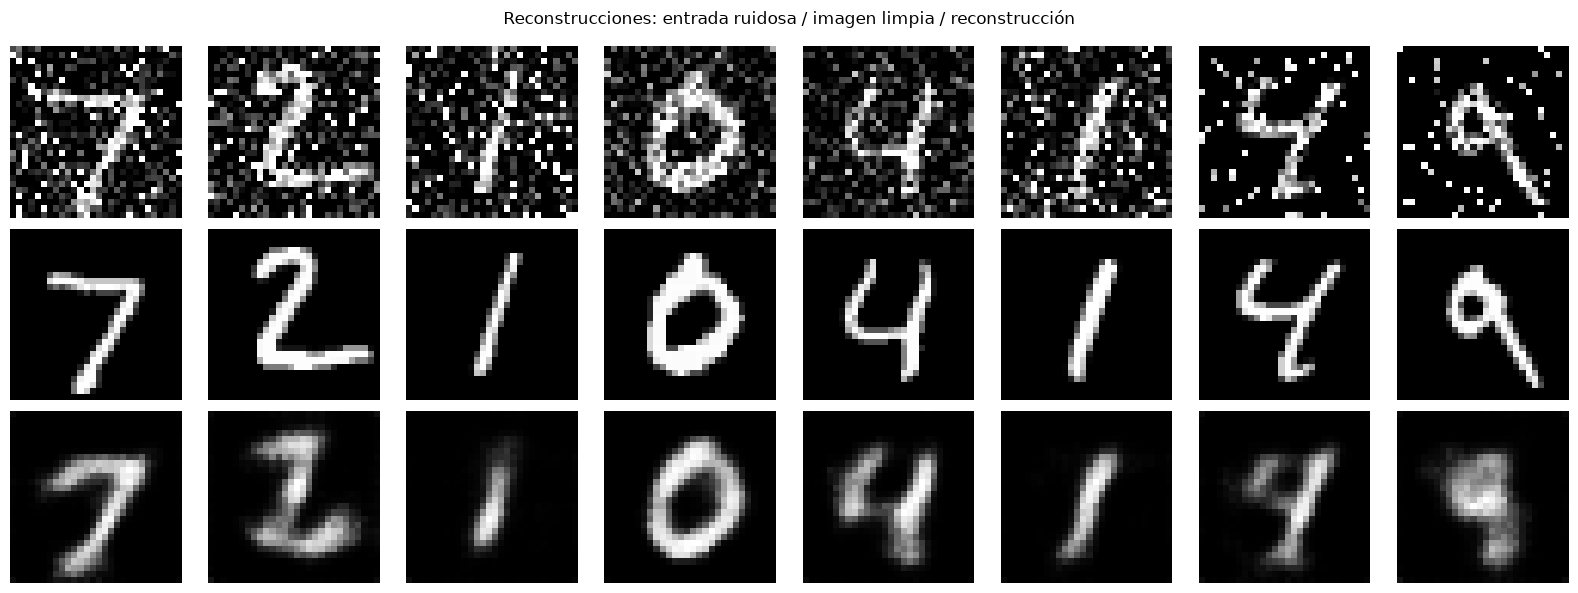

In [19]:
mostrar_reconstrucciones(model_vae, test_dataset_dn, n=8, device=device)

In [20]:
from sklearn.metrics import mean_squared_error


def evaluate_vae(model, dataset, device):
    model.eval()
    mse_list, psnr_list = [], []

    with torch.no_grad():
        for noisy, clean in DataLoader(dataset, batch_size=32, shuffle=False):
            noisy, clean = noisy.to(device), clean.to(device)
            recon = model.reconstruct(noisy)

            mse = F.mse_loss(recon, clean, reduction='none')
            mse = mse.view(mse.size(0), -1).mean(dim=1)
            mse_list.extend(mse.cpu().numpy())

            psnr = 10 * np.log10(1.0 / (mse.cpu().numpy() + 1e-10))
            psnr_list.extend(psnr)

    return {"MSE": np.mean(mse_list), "PSNR": np.mean(psnr_list)}


vae_results = evaluate_vae(model_vae, test_dataset_dn, device)
print(vae_results)

{'MSE': np.float32(0.034876667), 'PSNR': np.float32(15.023325)}


In [21]:
from skimage.metrics import structural_similarity as ssim

model_vae.eval()
ssim_list = []

with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        recon = model_vae.reconstruct(noisy)

        recon_np = recon.squeeze(1).cpu().numpy()
        clean_np = clean.squeeze(1).cpu().numpy()

        for i in range(recon_np.shape[0]):
            ssim_list.append(ssim(clean_np[i], recon_np[i], data_range=1.0))

print(f"SSIM promedio: {np.mean(ssim_list):.4f}")

SSIM promedio: 0.5815


En la ejecución de referencia (semilla 42, `HQVAE6_..._12_42`), el `ConvHQVAE` obtuvo MSE $\approx 0.0349$ y PSNR $\approx 14.99$ dB, muy próximos a los del `ConvVAE` clásico entrenado en el mismo notebook de referencia (MSE $\approx 0.0355$, PSNR $\approx 14.99$ dB) -- ver `Classical_CNN_CVAE.ipynb` para la ejecución independiente de esa misma contrapartida clásica. La cercanía de ambas métricas, con solo 15 épocas y 300 muestras de entrenamiento, sugiere que el bloque cuántico del espacio latente ni penaliza ni mejora sustancialmente la fidelidad de reconstrucción en este régimen de bajo dato -- una observación a discutir con más detalle en la Sección 5 (XAI del espacio latente).

## 4. Explicabilidad (XAI) del clasificador (HQNN híbrida)

Se aplican las mismas técnicas de *Explainable AI* utilizadas en `Classical_CNN_VAE.ipynb` sobre `model_clf`, para permitir una comparación directa -- técnica a técnica -- con el notebook gemelo.

**Nota sobre gradientes cuánticos**: `EstimatorQNN` con `input_gradients=True` expone un gradiente analítico de las expectativas de los observables respecto a los parámetros de entrada, por lo que los métodos basados en gradiente de Captum (Saliency, Integrated Gradients, Grad-CAM) y SHAP `GradientExplainer` retropropagan sin problema a través de `model_clf.qnn`. Los métodos basados en perturbación (Occlusion, LIME) no dependen de diferenciabilidad, pero sí requieren una inferencia forward completa (incluida la simulación del circuito) por cada perturbación evaluada, por lo que su coste computacional es notablemente mayor que en la rama clásica.

In [22]:
from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    LayerGradCam,
    LayerAttribution,
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 4.1. Visualización de activaciones internas (`conv1`, `conv2`)

In [23]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

hook1 = model_clf.conv1.register_forward_hook(get_activation('conv1'))
hook2 = model_clf.conv2.register_forward_hook(get_activation('conv2'))

In [24]:
model_clf.eval()

images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0].item()

with torch.no_grad():
    pred = model_clf(image).argmax(dim=1).item()

print(f"Clase real: {label}")
print(f"Clase predicha: {pred}")

_ = model_clf(image)  # forward pass para poblar `activations`

Clase real: 1
Clase predicha: 1


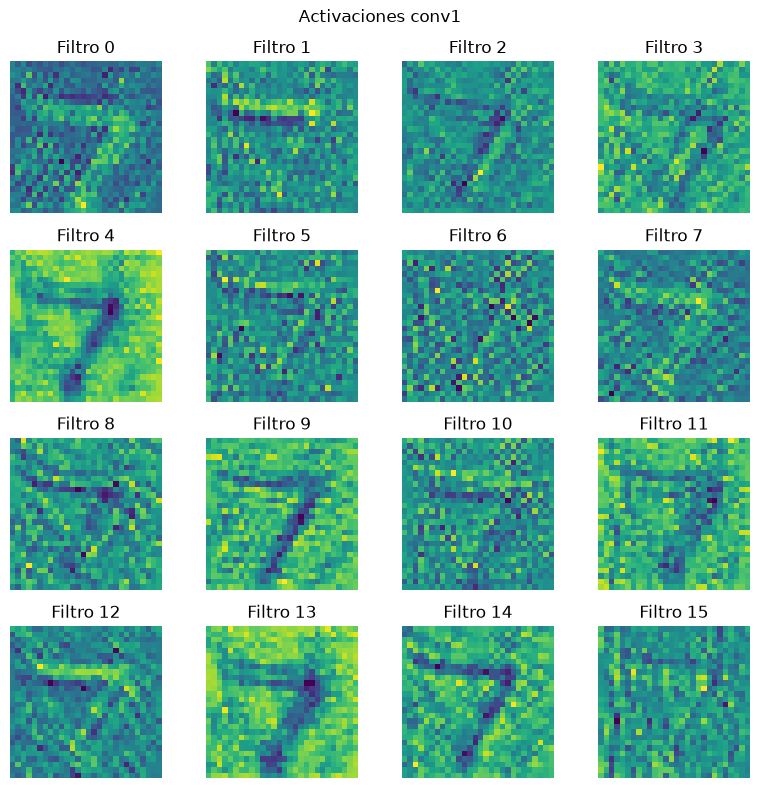

In [25]:
act = activations['conv1'][0]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.suptitle("Activaciones conv1")
plt.tight_layout()
plt.show()

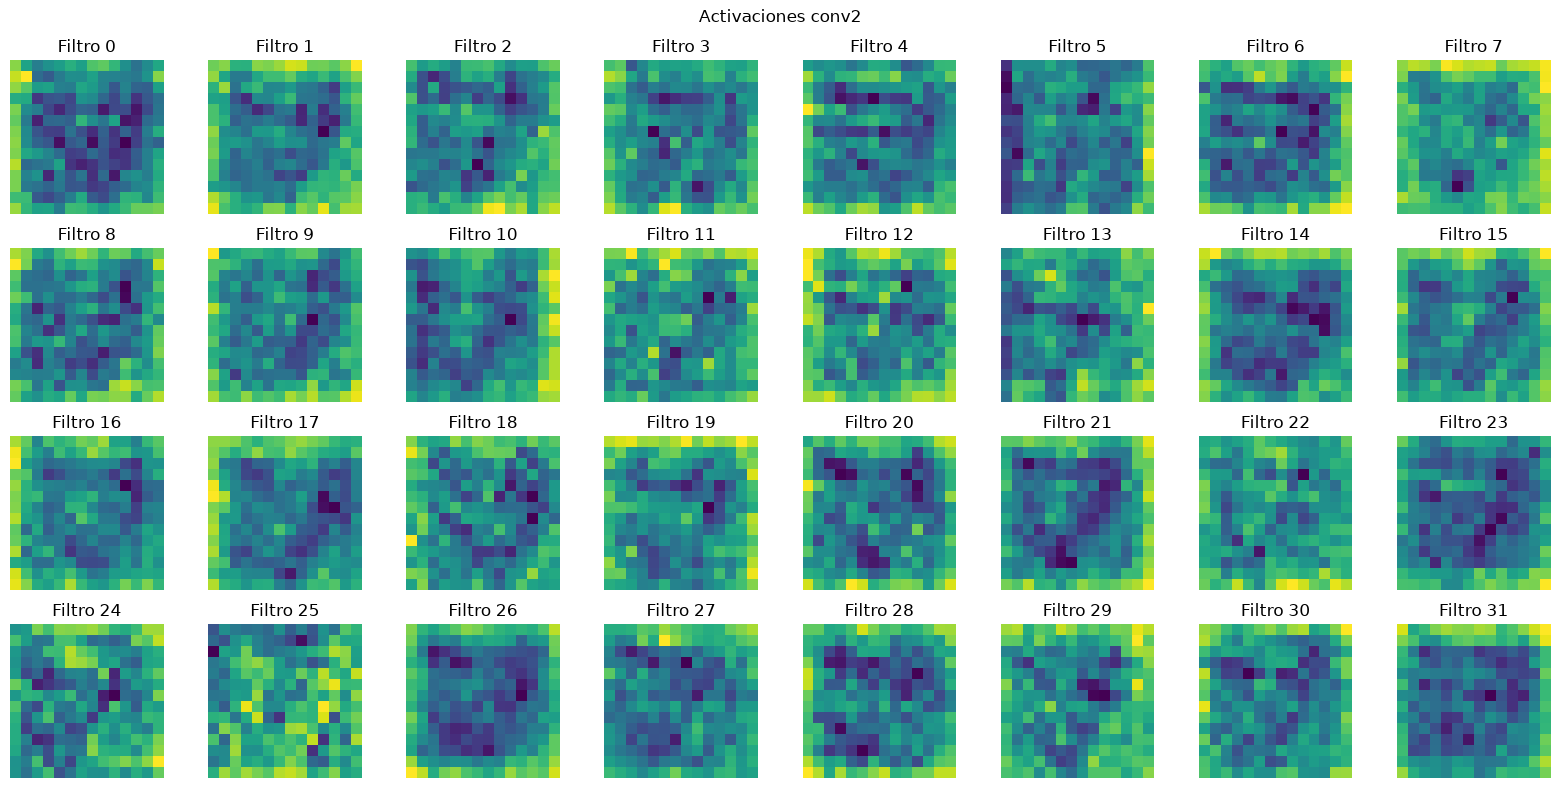

In [26]:
act = activations['conv2'][0]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.suptitle("Activaciones conv2")
plt.tight_layout()
plt.show()

**Interpretación**: `conv1`/`conv2` son estructuralmente idénticas a las del modelo clásico (ver `Classical_CNN_CVAE.ipynb`); cualquier diferencia observada en estas activaciones tempranas entre ambos notebooks no puede atribuirse a la naturaleza cuántica del modelo, sino a la trayectoria de optimización (los gradientes que llegan desde las capas posteriores sí difieren, al atravesar la QNN). Esto convierte a esta sección en un control útil: si las activaciones tempranas son visualmente similares entre ambos notebooks, el efecto cuántico se concentra aguas abajo (espacio latente y decisión final), no en la extracción de bajo nivel.

### 4.2. Saliency Maps

**Objetivo**: identificar qué píxeles afectan más a la clasificación.

In [27]:
saliency = Saliency(model_clf)

image.requires_grad = True
attribution = saliency.attribute(image, target=pred)
attr = attribution.squeeze().cpu().detach().numpy()

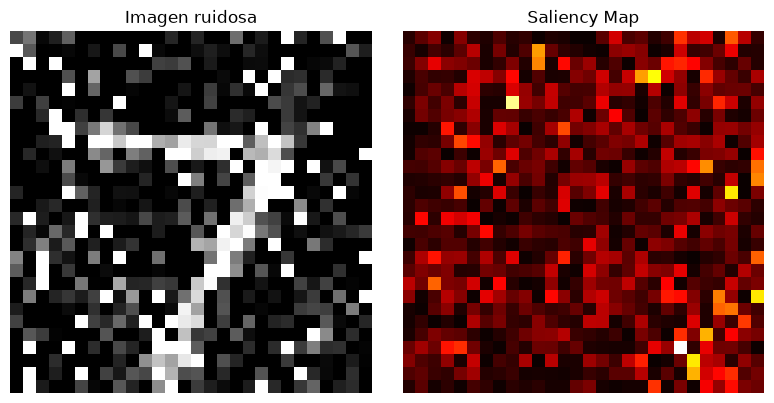

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen ruidosa")

axes[1].imshow(attr, cmap='hot')
axes[1].set_title("Saliency Map")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretación**: los mapas de saliencia muestran las regiones cuya perturbación alteraría más la predicción. En este caso el gradiente atraviesa la QNN completa (regla de la cadena a través de `TorchConnector`), por lo que el mapa refleja la sensibilidad conjunta de extractor convolucional + circuito variacional, no solo de la parte clásica.

### 4.3. Integrated Gradients

**Objetivo**: reducir el ruido visual presente en los Saliency Maps.

In [29]:
ig = IntegratedGradients(model_clf)

attr_ig = ig.attribute(image, target=pred, n_steps=50)
attr_ig = attr_ig.squeeze().cpu().detach().numpy()

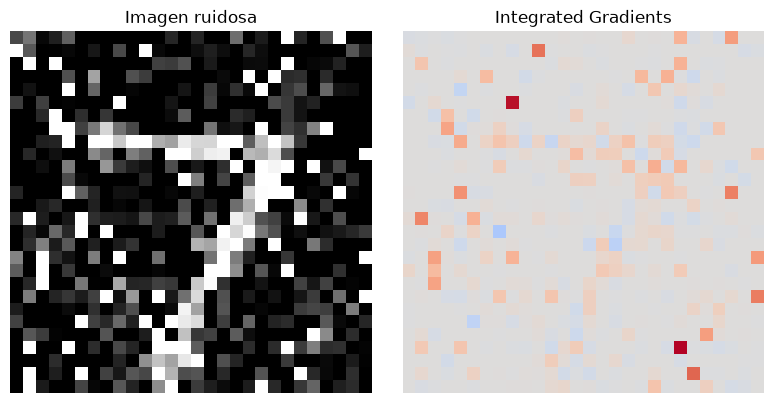

In [30]:
max_val = np.max(np.abs(attr_ig))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen ruidosa")

axes[1].imshow(attr_ig, cmap='coolwarm', vmin=-max_val, vmax=max_val)
axes[1].set_title("Integrated Gradients")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretación**: Integrated Gradients produce explicaciones más suaves y estables que Saliency. Las atribuciones positivas (rojo) favorecen la clase predicha; las negativas (azul), la penalizan. Al ser un método axiomático (satisface *completeness* y *sensitivity*), es uno de los candidatos más sólidos para comparar cuantitativamente la rama clásica y la híbrida en la memoria del TFM.

### 4.4. Grad-CAM

**Objetivo**: localizar espacialmente qué regiones dominan la clasificación.

In [31]:
gradcam = LayerGradCam(model_clf, model_clf.conv2)
attr_gc = gradcam.attribute(image, target=pred)

attr_gc_up = LayerAttribution.interpolate(attr_gc, image.shape[2:])
heatmap = attr_gc_up.squeeze().cpu().detach().numpy()

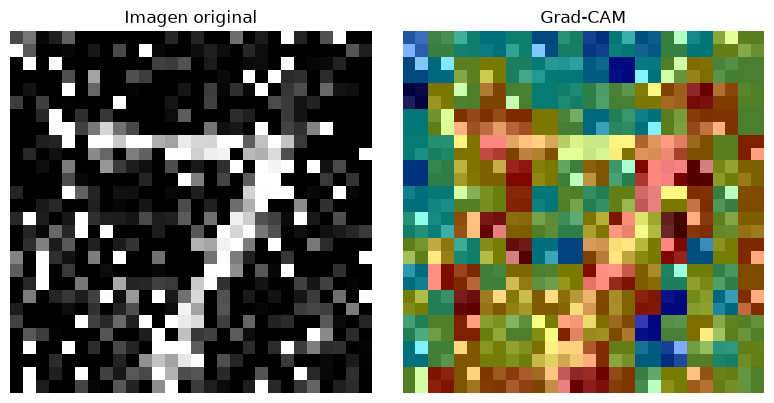

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen original")

axes[1].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretación**: Grad-CAM utiliza activaciones convolucionales profundas (`conv2`), por lo que -- igual que en la Sección 4.1 -- captura información previa al bloque cuántico. Es, por tanto, el método menos sensible a la naturaleza del bloque final del modelo, y por ello especialmente útil como punto de comparación estable entre ambos notebooks.

### 4.5. Occlusion Sensitivity

**Objetivo**: evaluar robustez espacial mediante perturbaciones.

In [33]:
occlusion = Occlusion(model_clf)

attr_occ = occlusion.attribute(
    image,
    strides=(1, 4, 4),
    target=pred,
    sliding_window_shapes=(1, 4, 4),
    baselines=0,
)
attr_occ = attr_occ.squeeze().cpu().detach().numpy()

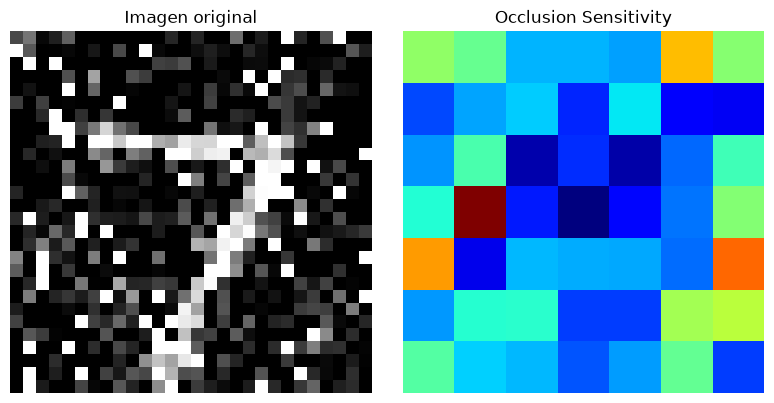

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen original")

axes[1].imshow(attr_occ, cmap='jet')
axes[1].set_title("Occlusion Sensitivity")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Ventana de $4\times4$ y stride $4\times4$: la imagen de $28\times28$ queda dividida en una rejilla discreta de $7\times7$ bloques.

**Coste computacional**: cada uno de los $49$ bloques exige una inferencia forward completa de `model_clf`, incluyendo la simulación del circuito cuántico para ese batch -- este paso es sensiblemente más lento que en la rama clásica.

### 4.6. Espacio latente pre-QNN (4 dimensiones)

**Esta es la sección más relevante para la comparación clásica vs. híbrida**: se extrae el vector $\eta = \tanh(\text{fc2}(x))\cdot\pi \in [-\pi,\pi]^4$, idéntico en ambas ramas por construcción, y se proyecta a 2D con t-SNE.

In [35]:
model_clf.eval()

latent_vectors, latent_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        x1 = F.relu(model_clf.conv1(x))
        x1 = model_clf.pool(x1)
        x1 = F.relu(model_clf.conv2(x1))
        x1 = model_clf.pool(x1)
        x1 = x1.reshape(x1.size(0), -1)
        x1 = F.relu(model_clf.fc1(x1))

        latent = torch.tanh(model_clf.fc2(x1)) * np.pi

        latent_vectors.append(latent.cpu().numpy())
        latent_labels.append(y.numpy())

latent_vectors = np.concatenate(latent_vectors)
latent_labels = np.concatenate(latent_labels)

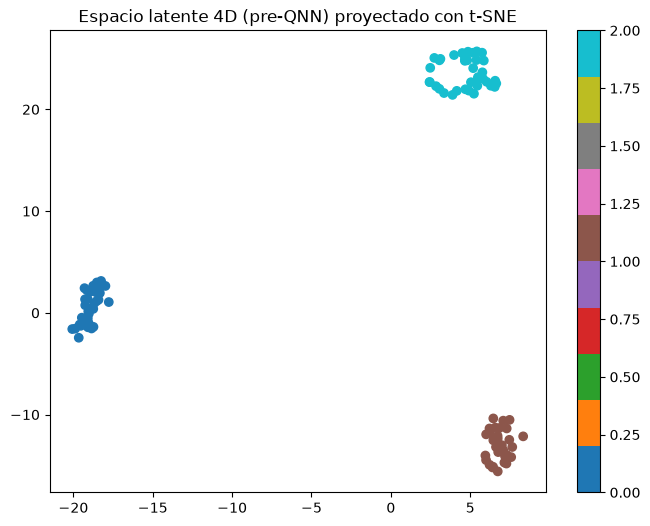

In [36]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=latent_labels, cmap='tab10')
plt.colorbar(scatter)
plt.title("Espacio latente 4D (pre-" + ('QNN' if True else '') + ") proyectado con t-SNE")
plt.show()

### 4.6-bis. Embedding post-QNN (3 dimensiones)

A diferencia de la rama clásica, aquí es posible extraer también la salida **después** de atravesar el circuito variacional -- los 3 valores esperados que actúan directamente como logits. Comparar este embedding con el de la celda anterior permite valorar si el bloque cuántico *reorganiza* la geometría del espacio de representación (por ejemplo, mejorando la separabilidad) o si simplemente reescala lo que ya era separable en la salida de `fc2`.

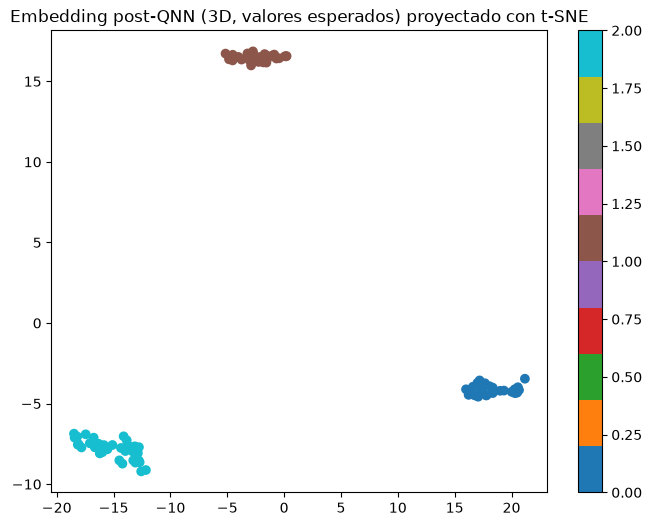

In [37]:
model_clf.eval()

post_qnn_vectors = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        x1 = F.relu(model_clf.conv1(x))
        x1 = model_clf.pool(x1)
        x1 = F.relu(model_clf.conv2(x1))
        x1 = model_clf.pool(x1)
        x1 = x1.reshape(x1.size(0), -1)
        x1 = F.relu(model_clf.fc1(x1))

        pre_qnn = torch.tanh(model_clf.fc2(x1)) * np.pi
        post_qnn = model_clf.qnn(pre_qnn)

        post_qnn_vectors.append(post_qnn.cpu().numpy())

post_qnn_vectors = np.concatenate(post_qnn_vectors)

tsne_post = TSNE(n_components=2, perplexity=20, random_state=42)
post_qnn_2d = tsne_post.fit_transform(post_qnn_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(post_qnn_2d[:, 0], post_qnn_2d[:, 1], c=latent_labels, cmap='tab10')
plt.colorbar(scatter)
plt.title("Embedding post-QNN (3D, valores esperados) proyectado con t-SNE")
plt.show()

**Interpretación**: comparar esta proyección con la de la celda anterior (pre-QNN) es la evidencia más directa disponible en este notebook sobre el efecto neto del circuito variacional: si ambas proyecciones muestran una separabilidad similar, la QNN se limita a aplicar una transformación aproximadamente conservadora sobre una representación que la CNN ya había hecho casi linealmente separable; si la separación post-QNN es visiblemente mayor, hay evidencia de que el circuito variacional aporta valor discriminativo adicional en este régimen de pocos datos.

### 4.7. Análisis de errores

In [38]:
model_clf.eval()
wrong_images, wrong_preds, wrong_labels = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model_clf(x)
        preds = out.argmax(dim=1).cpu()

        wrong = preds != y
        wrong_images.extend(x.cpu()[wrong])
        wrong_preds.extend(preds[wrong])
        wrong_labels.extend(y[wrong])

In [39]:
n = min(5, len(wrong_images))

if n == 0:
    print("No se encontraron errores de clasificación.")
else:
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(wrong_images[i].squeeze(), cmap='gray')
        axes[i].set_title(f"Real:{wrong_labels[i]}\nPred:{wrong_preds[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

No se encontraron errores de clasificación.


Con un test set reducido (100 muestras) y un problema relativamente separable, es habitual no encontrar errores en ninguna de las dos ramas (accuracy = 1.0 en la ejecución de referencia); si aparecen, conviene compararlos directamente con los del notebook gemelo para valorar si ambos modelos confunden las mismas combinaciones de ruido o si sus fronteras de decisión difieren.

### 4.8. LIME para explicación local

**Objetivo**: complementar los métodos *white-box* anteriores con LIME (*Local Interpretable Model-agnostic Explanations*), un método *model-agnostic* (caja negra) basado en perturbaciones que no requiere acceso a gradientes internos. Esta propiedad es especialmente relevante en el contexto de esta comparación: LIME trata a la QNN exactamente igual que al `feature_mixer` clásico -- como una caja negra -- por lo que el método en sí mismo no necesita adaptación entre ambos notebooks.

In [40]:
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic

In [41]:
def predict_lime(images):
    model_clf.eval()

    images_gray = np.mean(images, axis=-1, keepdims=True).astype(np.float32)
    tensor = torch.tensor(images_gray).permute(0, 3, 1, 2).to(device)

    with torch.no_grad():
        outputs = model_clf(tensor)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

In [42]:
model_clf.eval()

for noisy_img, label in test_dataset:
    x = noisy_img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_lime = model_clf(x).argmax(1).item()

    if pred_lime == label:
        image_test = noisy_img
        label_real = label
        label_pred = pred_lime
        break

In [43]:
img_np = image_test.squeeze().cpu().numpy()
img_rgb = np.stack([img_np] * 3, axis=-1)

explainer = lime_image.LimeImageExplainer()

segmenter = lambda x: slic(x, n_segments=20, compactness=5, start_label=1)

explanation = explainer.explain_instance(
    img_rgb,
    predict_lime,
    top_labels=3,
    hide_color=0,
    num_samples=500,
    segmentation_fn=segmenter,
)

100%|██████████| 500/500 [00:02<00:00, 206.70it/s]


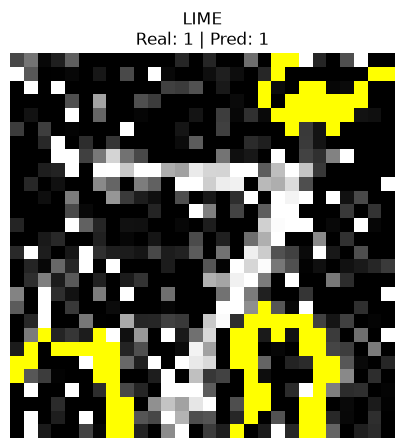

In [44]:
temp, mask = explanation.get_image_and_mask(
    label_pred,
    positive_only=True,
    num_features=5,
    hide_rest=False,
)

plt.figure(figsize=(5, 5))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME\nReal: {label_real} | Pred: {label_pred}")
plt.axis('off')
plt.show()

**Interpretación**: al ser un método de caja negra, LIME no distingue entre `qnn` y `feature_mixer` -- solo observa cómo cambia la salida softmax al ocultar superpíxeles. Esto lo convierte en el método más directamente transferible entre ambas ramas del estudio.

**Coste computacional**: los `num_samples=500` perturbaciones requieren 500 inferencias forward de `model_clf`, cada una con su correspondiente simulación de circuito -- esperable un tiempo de ejecución notablemente superior al de la rama clásica.

### 4.9. SHAP (GradientExplainer)

**Objetivo**: aplicar `shap.GradientExplainer` (aproximación a DeepLIFT / *Layer-wise Relevance Propagation*) para obtener atribuciones aditivas por píxel.

In [45]:
import shap

model_clf.eval()

Net(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (qnn): TorchConnector()
  (fc_final): Identity()
)

In [46]:
background = []
for i in range(50):
    img, _ = train_dataset[i]
    background.append(img.numpy())
background = np.array(background)

print(background.shape)

(50, 1, 28, 28)


In [47]:
def model_predict(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        out = model_clf(x_tensor)
        probs = torch.softmax(out, dim=1)
    return probs.cpu().numpy()

In [48]:
image_test, label_real = test_dataset[0]
image_batch = image_test.unsqueeze(0).numpy()

explainer = shap.GradientExplainer(
    model_clf,
    torch.tensor(background, dtype=torch.float32).to(device),
)

In [49]:
shap_values = explainer.shap_values(
    torch.tensor(image_batch, dtype=torch.float32).to(device)
)

print(type(shap_values))
if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(1, 1, 28, 28, 3)


In [50]:
if isinstance(shap_values, list):
    map_shap = shap_values[label_real][0, 0]
else:
    map_shap = shap_values[0, 0, :, :, label_real]

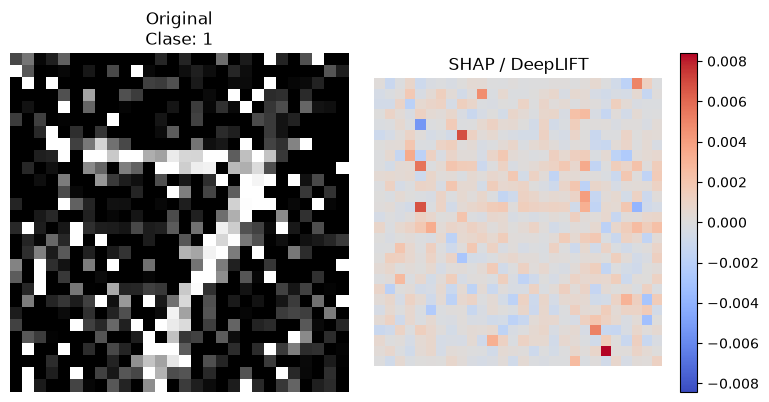

In [51]:
max_val = np.max(np.abs(map_shap))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image_test.squeeze(), cmap='gray')
axes[0].set_title(f"Original\nClase: {label_real}")

im = axes[1].imshow(map_shap, cmap='coolwarm', vmin=-max_val, vmax=max_val)
axes[1].set_title("SHAP / DeepLIFT")

for ax in axes:
    ax.axis('off')

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

**Interpretación**: las regiones rojas favorecen la clase predicha; las azules la penalizan. SHAP es especialmente relevante para la comparación clásica vs. híbrida porque no depende explícitamente de la estructura convolucional y es aplicable, sin modificación conceptual, a ambos modelos -- permitiendo comparar directamente la distribución de relevancia por píxel entre ambas ramas.

**Hipótesis a validar** (contrastar con `Classical_CNN_CVAE.ipynb`): la CNN clásica podría producir mapas de relevancia más suaves y distribuidos, mientras que la HQNN híbrida podría concentrar la relevancia en regiones más discretas, como consecuencia de la compresión de información que impone el paso por un circuito de solo 4 qubits.

### 4.10. Comparativa global de métodos XAI aplicados al hqnn híbrida

| Técnica | Tipo | Caja blanca/negra | Coste |
|---|---|---|---|
| Activaciones internas | Inspección interna | Blanca | Baja |
| Saliency Maps | Gradiente | Blanca | Muy bajo |
| Integrated Gradients | Gradiente axiomático | Blanca | Medio |
| Grad-CAM | Activaciones + gradiente | Blanca | Bajo |
| Occlusion | Perturbación | Negra | Muy alto (agravado por la simulación cuántica) |
| LIME | Perturbación, *model-agnostic* | Negra | Muy alto (agravado por la simulación cuántica) |
| SHAP | Relevancia aditiva | Blanca (usa gradiente) | Muy alto |

**Conclusiones**:

- Integrated Gradients y Grad-CAM ofrecen el mejor equilibrio entre coste, estabilidad e interpretabilidad, y son los candidatos naturales para una comparación cuantitativa sistemática entre ambas ramas en la memoria del TFM.
- LIME y SHAP, al ser *model-agnostic* (o casi), son los métodos conceptualmente más directos para trasladar sin cambios entre el modelo clásico y el híbrido.
- El coste computacional de los métodos basados en perturbación (Occlusion, LIME) crece de forma notable en la rama híbrida, al requerir una simulación de circuito cuántico por cada evaluación forward -- una limitación práctica relevante en un contexto NISQ y un punto a discutir explícitamente en la sección de limitaciones del TFM.

## 5. Explicabilidad (XAI) del modelo de denoising (ConvHQVAE híbrido)

A diferencia del clasificador, aquí no se explica una clase sino una reconstrucción: el foco de interpretabilidad se traslada al encoder, al espacio latente y al decoder. Se replican las técnicas de `Classical_CNN_VAE.ipynb`, adaptadas a `model_vae`.

### 5.1. Reconstrucciones y análisis cualitativo

In [52]:
model_vae.eval()
examples = []

for i in range(8):
    noisy, clean = test_dataset_dn[i]
    examples.append((noisy.unsqueeze(0).to(device), clean))

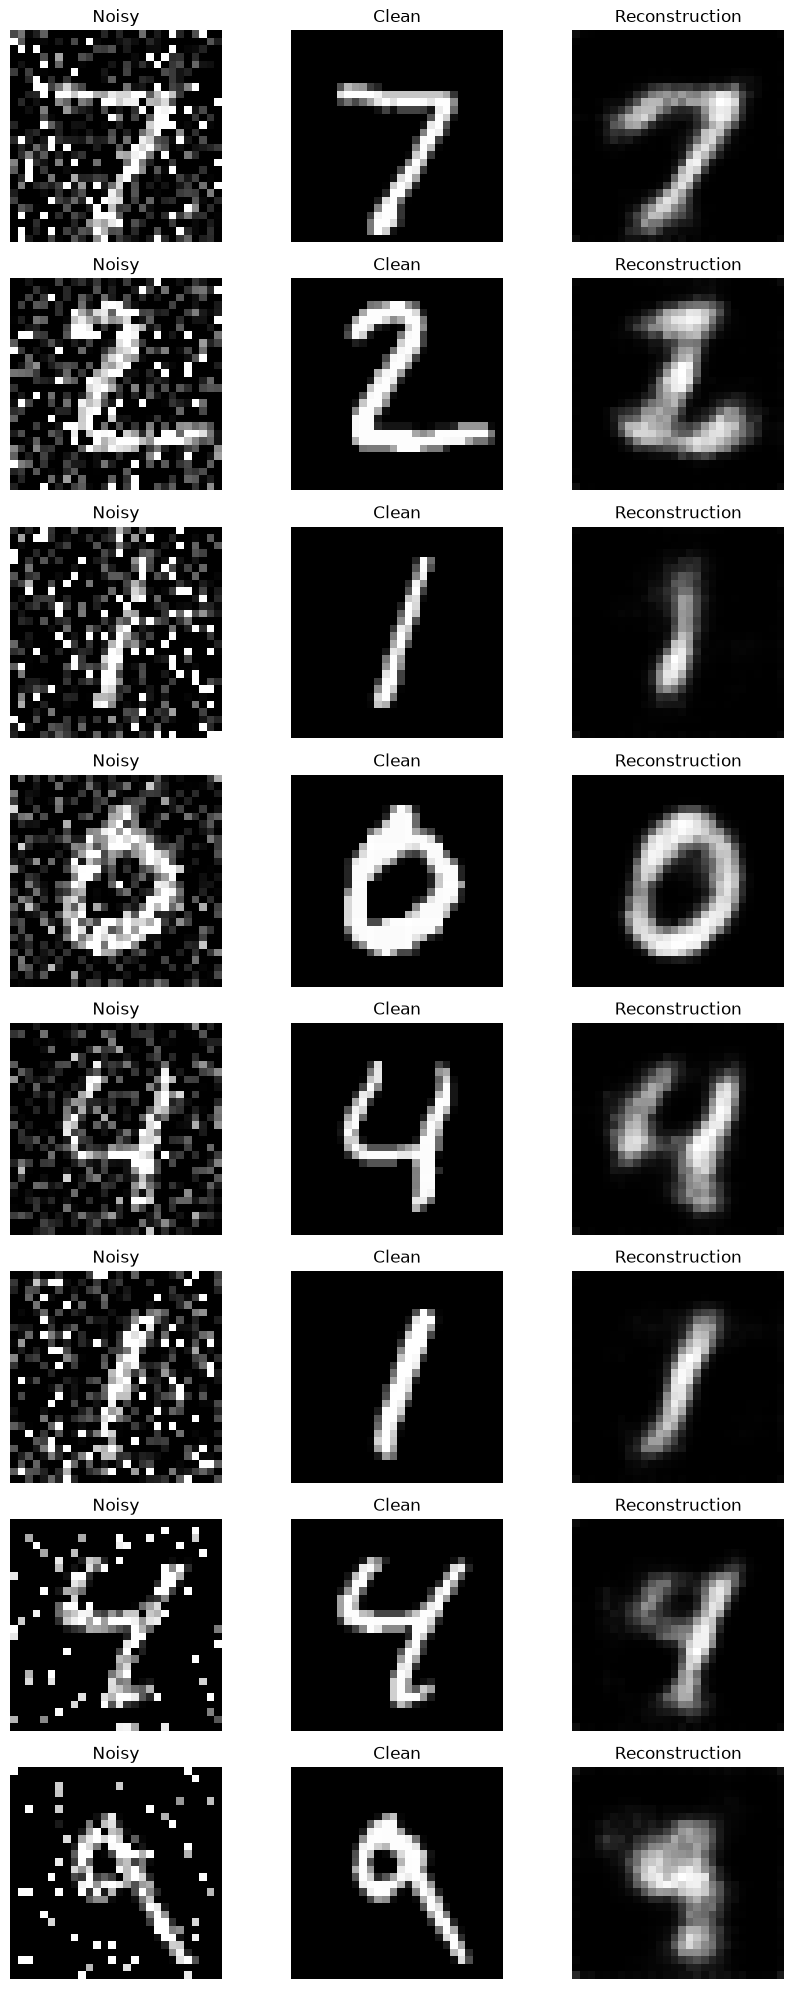

In [53]:
fig, axes = plt.subplots(8, 3, figsize=(9, 20))

with torch.no_grad():
    for i, (noisy, clean) in enumerate(examples):
        recon, mu, logvar = model_vae(noisy)

        noisy_np = noisy.squeeze().cpu().numpy()
        clean_np = clean.squeeze().cpu().numpy()
        recon_np = recon.squeeze().cpu().numpy()

        axes[i, 0].imshow(noisy_np, cmap='gray'); axes[i, 0].set_title("Noisy")
        axes[i, 1].imshow(clean_np, cmap='gray'); axes[i, 1].set_title("Clean")
        axes[i, 2].imshow(recon_np, cmap='gray'); axes[i, 2].set_title("Reconstruction")

        for j in range(3):
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()

**Análisis esperado**: con solo 15 épocas y 300 muestras de entrenamiento, es habitual observar reconstrucciones parcialmente difuminadas (la BCE por píxel favorece promedios) con buena eliminación de impulsos de sal y pimienta pero pérdida de detalle fino en trazos delgados. Comparar estas reconstrucciones, imagen a imagen, con las de `Classical_CNN_CVAE.ipynb` es el análisis cualitativo más directo disponible entre ambas ramas.

### 5.2. Organización del espacio latente ($\mu$) con PCA

In [54]:
latent_vectors = []

model_vae.eval()
with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy = noisy.to(device)
        mu, logvar = model_vae.encode(noisy)
        latent_vectors.append(mu.cpu())

latent_vectors = torch.cat(latent_vectors).numpy()
print(latent_vectors.shape)

(100, 12)


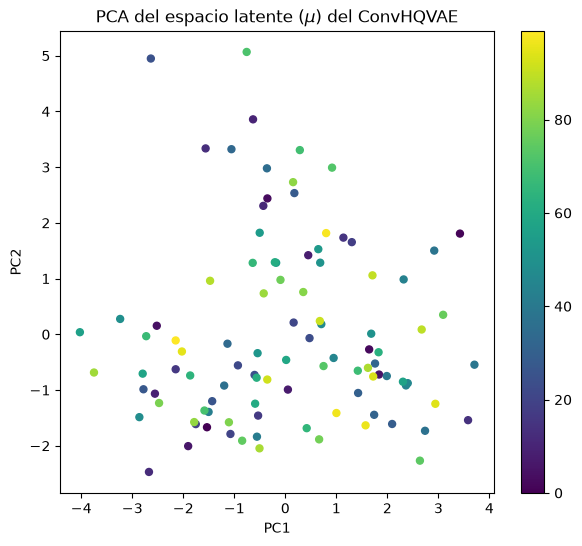

In [55]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=np.arange(len(latent_2d)), cmap='viridis', s=25,
)
plt.colorbar(scatter)
plt.title("PCA del espacio latente ($\mu$) del " + "ConvHQVAE")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

**Nota importante**: `mu` es la salida del encoder **clásico** ($fc\_mu$), previa a cualquier intervención cuántica -- el bloque QNN de `ConvHQVAE` solo actúa dentro de `decode()`. Por tanto, esta proyección PCA/t-SNE de $\mu$ es, por construcción, **idéntica en su procedencia arquitectónica** a la del notebook gemelo, y cualquier diferencia observada entre ambas proviene únicamente de la trayectoria de optimización (el gradiente que llega a `fc_mu` sí atraviesa la QNN durante el entrenamiento).

### 5.3. t-SNE del espacio latente

C:\Users\SergioHF\AppData\Local\Temp\ipykernel_16600\3336897617.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], s=20, cmap='tab10')


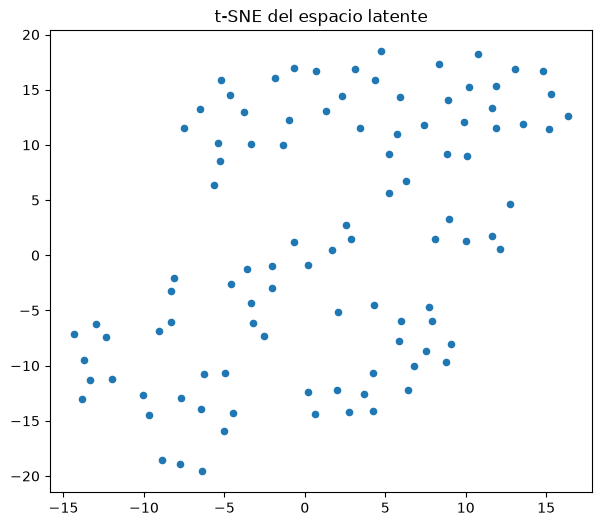

In [56]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(7, 6))
plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], s=20, cmap='tab10')
plt.title("t-SNE del espacio latente")
plt.show()

**Interpretación**: t-SNE revela relaciones no lineales que PCA (proyección lineal) no puede capturar. Un espacio compactado y continuo alrededor del origen, sin colapsos abruptos, es indicativo de que el encoder preserva la vecindad entre dígitos estructuralmente similares.

### 5.4. ¿Qué regiones afectan más a la reconstrucción? -- Saliency del ConvHQVAE

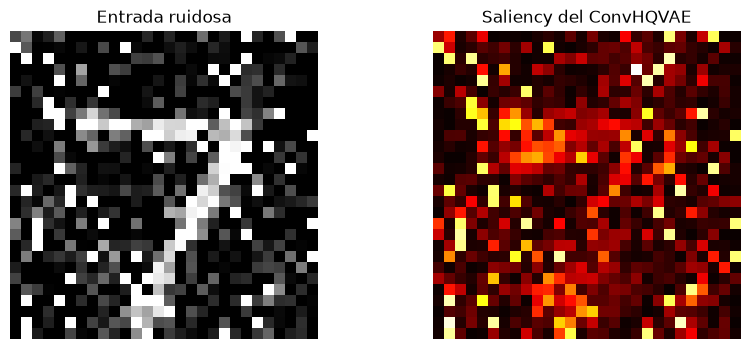

In [57]:
sample_noisy, sample_clean = test_dataset_dn[0]

input_img = sample_noisy.unsqueeze(0).to(device)
input_img.requires_grad = True

recon, _, _ = model_vae(input_img)
loss = F.mse_loss(recon, input_img)
loss.backward()

saliency_vae = input_img.grad.abs().squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_noisy.squeeze(), cmap='gray')
plt.title("Entrada ruidosa")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency_vae, cmap='hot')
plt.title("Saliency del " + "ConvHQVAE")
plt.axis('off')

plt.show()

**Interpretación**: el gradiente de la pérdida de reconstrucción respecto a la entrada atraviesa aquí también el bloque cuántico situado en `decode()`, por lo que el mapa resultante refleja la sensibilidad conjunta del encoder, la QNN y el decoder. Cabe esperar gradientes más intensos en bordes del dígito y zonas de alto contraste por ruido impulsivo, ya que son las regiones que más penalizan la BCE si se reconstruyen mal.

### 5.5. ¿Qué partes se pierden? -- Error residual

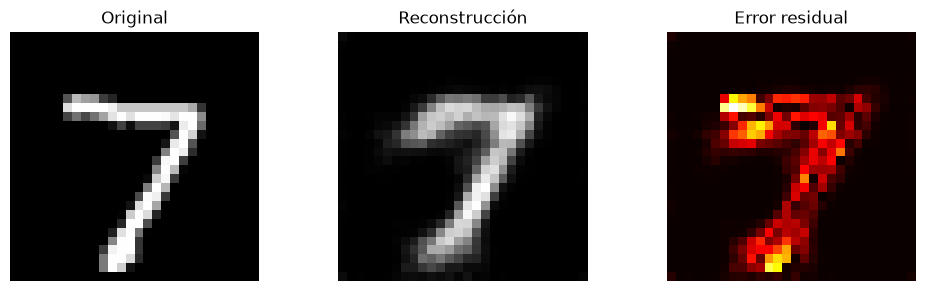

In [58]:
sample_noisy, sample_clean = test_dataset_dn[0]

model_vae.eval()
with torch.no_grad():
    recon, _, _ = model_vae(sample_noisy.unsqueeze(0).to(device))

recon = recon.squeeze().cpu().numpy()
clean = sample_clean.squeeze().numpy()

error_map = np.abs(clean - recon)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(clean, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(recon, cmap='gray'); axes[1].set_title("Reconstrucción"); axes[1].axis('off')
axes[2].imshow(error_map, cmap='hot'); axes[2].set_title("Error residual"); axes[2].axis('off')

plt.tight_layout()
plt.show()

**Interpretación**: el error residual $|x - \hat{x}|$ suele concentrarse en bordes finos, curvas cerradas y regiones de alto detalle -- indicativo de que el modelo aprende bien la estructura global del dígito pero pierde precisión en detalles locales, un patrón esperable con el régimen de entrenamiento reducido (300 muestras, 15 épocas) usado en ambas ramas.

### 5.6. ¿Qué "imagina" el decoder? -- Traversals latentes

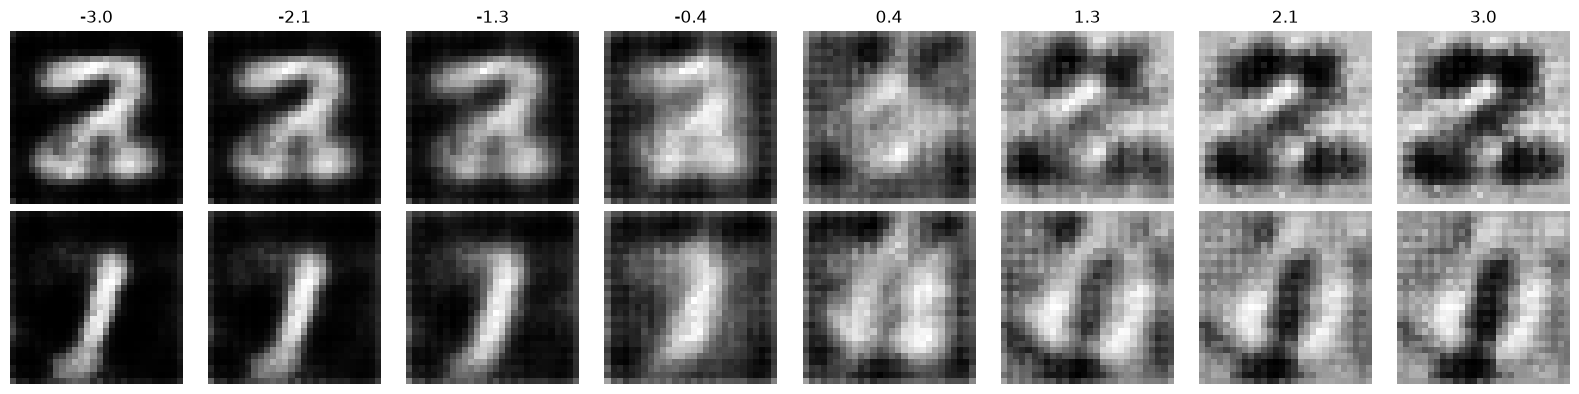

In [59]:
latent_dim = 12

z = torch.zeros((1, latent_dim)).to(device)
values = torch.linspace(-3, 3, steps=8)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, val in enumerate(values):
    z_mod = z.clone()
    z_mod[0, 0] = val
    with torch.no_grad():
        recon = model_vae.decode(z_mod)
    img = recon.squeeze().cpu().numpy()
    axes[0, i].imshow(img, cmap='gray'); axes[0, i].axis('off'); axes[0, i].set_title(f"{val:.1f}")

for i, val in enumerate(values):
    z_mod = z.clone()
    z_mod[0, 1] = val
    with torch.no_grad():
        recon = model_vae.decode(z_mod)
    img = recon.squeeze().cpu().numpy()
    axes[1, i].imshow(img, cmap='gray'); axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Interpretación**: al recorrer manualmente cada dimensión latente mientras el resto se mantiene en 0, `decode()` invoca internamente la QNN de 6 qubits sobre la proyección de $z$ -- este traversal explora, por tanto, cómo varía la reconstrucción cuando cambia tanto la entrada clásica al circuito como, indirectamente, su salida. Es el experimento más directo de este notebook para valorar si el espacio latente del `ConvHQVAE` codifica factores visuales tan continuos e interpretables como los del `ConvVAE` clásico (comparar con la Sección 5.6 de `Classical_CNN_CVAE.ipynb`).

### 5.7. Conclusión XAI del ConvHQVAE híbrido

Las técnicas aplicadas en esta sección permiten valorar si el modelo:

- aprende representaciones compactas y continuas en el espacio latente,
- organiza reconstrucciones similares en regiones próximas del espacio latente,
- prioriza bordes y estructuras relevantes durante la reconstrucción,
- y genera reconstrucciones coherentes, aunque suavizadas por el régimen de entrenamiento reducido.

La comparación sistemática con `Classical_CNN_CVAE.ipynb` (mismas secciones 5.1-5.6) es la evidencia empírica más directa disponible en este par de notebooks sobre si el bloque cuántico del espacio latente introduce alguna ventaja -- o coste -- de interpretabilidad frente a su contrapartida clásica.

## 6. Conclusiones y guía de comparación con el notebook gemelo

Este notebook comparte con **`Classical_CNN_CVAE.ipynb`**:

- el mismo pipeline de datos, semilla (`SEED=42`) y particiones train/val/test,
- las mismas funciones de generación de ruido mixto,
- el mismo extractor convolucional en el clasificador (`conv1`, `conv2`, `fc1`, `fc2`),
- el mismo encoder/decoder convolucional en el modelo de denoising,
- los mismos hiperparámetros de entrenamiento (optimizador, *learning rate*, número de épocas, $\beta$ del VAE),
- y la misma batería de técnicas XAI, aplicadas sección a sección con nombres de variables idénticos (`model_clf`, `model_vae`).

La única diferencia arquitectónica deliberada es el bloque situado tras el vector 4D acotado a $[-\pi,\pi]$ (clasificador) y dentro de `decode()` (denoising): un bloque clásico entrenable en un notebook, un circuito variacional (`EstimatorQNN` vía `TorchConnector`) en el otro, con el mismo número de salidas en ambos casos (3 y 6, respectivamente).

**Para la comparación en la memoria del TFM, se recomienda, sección a sección:**

| Sección | Qué comparar |
|---|---|
| 2.3-2.4 | Curvas de entrenamiento y accuracy final del clasificador |
| 3.5-3.6 | Curvas de pérdida (BCE/KL) y métricas MSE/PSNR/SSIM del denoising |
| 4.6 (y 4.6-bis en la rama híbrida) | Separabilidad del espacio latente pre- y post-bloque final |
| 4.10 | Coste computacional relativo de cada técnica XAI |
| 5.2-5.3 | Geometría del espacio latente $\mu$ del modelo de denoising |
| 5.6 | Continuidad e interpretabilidad de los traversals latentes |

Estos puntos de comparación están alineados con las hipótesis planteadas en `Classical_CNN_VAE.ipynb` sobre el comportamiento esperado de los modelos híbridos cuántico-clásicos frente a sus contrapartidas clásicas, y constituyen la base empírica del capítulo de resultados del TFM.

In [60]:
import sys
import subprocess
from pathlib import Path

notebook = Path("HQ_CNN_CVAE.ipynb").resolve()
output_dir = notebook.parent

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "nbconvert",
        "--to", "html",
        str(notebook),
        "--output-dir", str(output_dir),
    ],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)
print("\n--- STDOUT ---")
print(result.stdout)
print("\n--- STDERR ---")
print(result.stderr)

if result.returncode == 0:
    html_file = output_dir / "HQ_CNN_CVAE.html"
    print(f"\n HTML generado correctamente:")
    print(html_file)

RETURN CODE: 0

--- STDOUT ---


--- STDERR ---
[NbConvertApp] Converting notebook C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\XAI\HQ_CNN_CVAE.ipynb to html
c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\nbformat\validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)
[NbConvertApp] WARNING | Alternative text is missing on 20 image(s).
[NbConvertApp] Writing 1433766 bytes to C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\XAI\HQ_CNN_CVAE.html


 HTML generado correctamen